Part 1: Univariate Analysis
1. Task 1: Histogram
- Create histogram for:
• Price
• Area
- Questions:
• Is the distribution normal, skewed left, or skewed
right?
• Are there extreme values?
2. Task 2: Boxplot
- Create boxplot for:
• Price
• Area
- Questions:
• Explain the graph based on what you see
3. Task 3: Bar Chart
- Create bar chart:
• Average price by number of bedrooms
- Questions:
• Does price increase with bedrooms?
• Is it always increasing?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('house_prices.csv')
df



,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,N,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,N,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,N,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,N,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


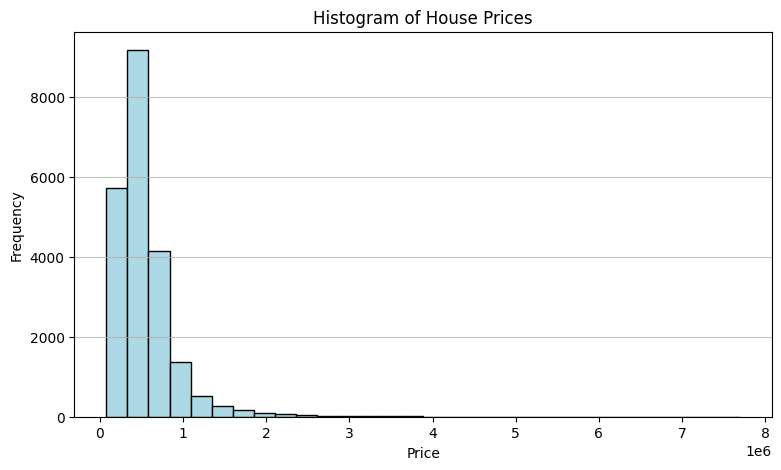

In [2]:
plt.figure(figsize=(9, 5))
plt.hist(df['price'], bins=30, color='lightblue', edgecolor='black')
plt.title('Histogram of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Is the distribution normal, skewed left, or skewed right?

- The distribution is skewed right because most houses are cheap.

Are there extreme values?

- Yes, because some houses cost alot more than most others.

2. Task 2: Boxplot


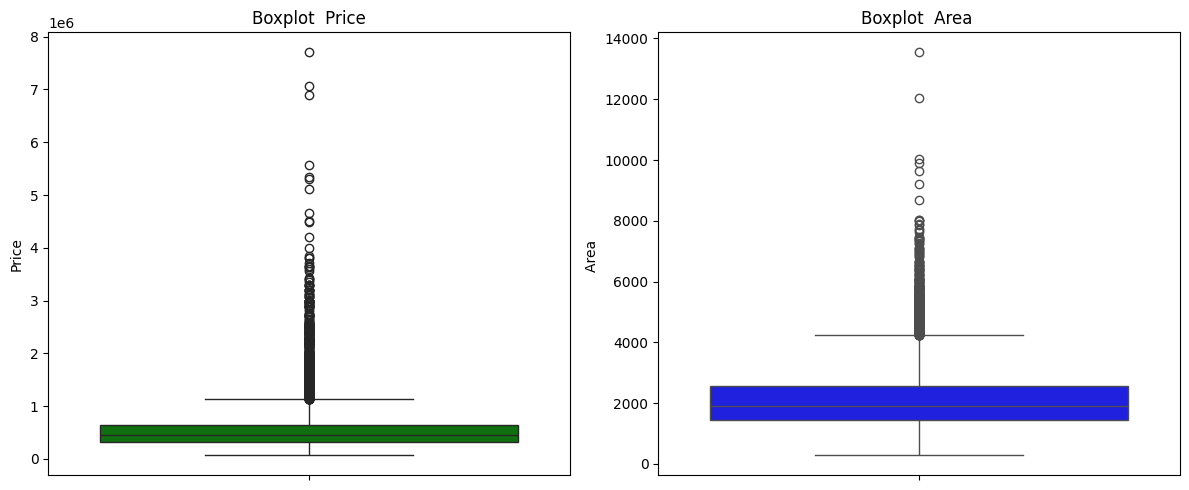

In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['price'], color='green')
plt.title('Boxplot  Price')
plt.ylabel('Price')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['sqft_living'], color='blue') 
plt.title('Boxplot  Area ')
plt.ylabel('Area ')
plt.tight_layout()
plt.show()

This graph show some houses is expensive causing them have some outliers. so do Area because some houses are having alot of area compare to other regular houses

Task 3: Bar Chart

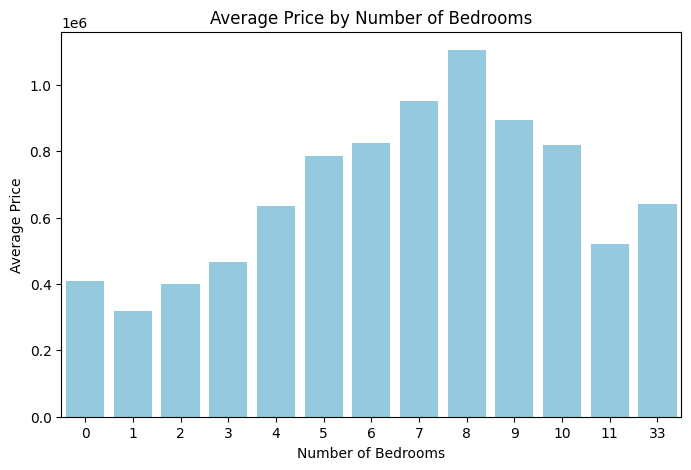

In [6]:
avgPriceByBedrooms = df.groupby('bedrooms')['price'].mean().sort_index()
plt.figure(figsize=(8, 5))
sns.barplot(
    x=avgPriceByBedrooms.index,
    y=avgPriceByBedrooms.values,
    color='skyblue'
)
plt.title('Average Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average Price')
plt.show()

Does price increase with bedrooms?
- no it doesn't

Is it always increasing?
- Not really bacause only between room 1-8 seen increase but  from 9 to 33 the number doesn't seen to increase

4. Task 4: Scatter Plot

- Plot:

• Area vs Price

• Add regression line (Seaborn).

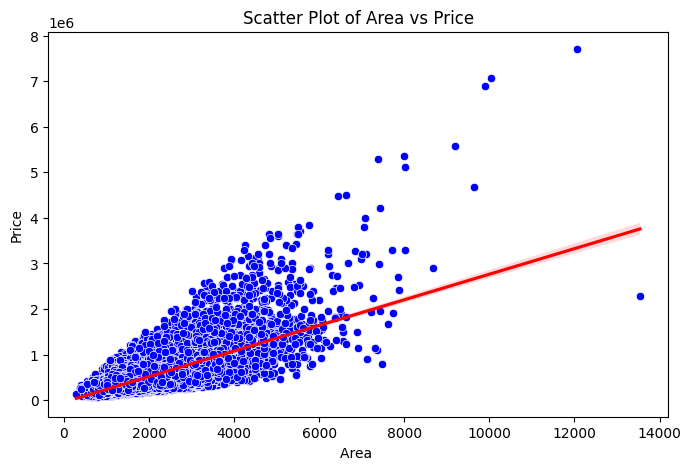

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['sqft_living'], y=df['price'], color='blue')
sns.regplot(x=df['sqft_living'], y=df['price'], scatter=False, color='red')
plt.title('Scatter Plot of Area vs Price')
plt.xlabel('Area ')
plt.ylabel('Price')
plt.show()

Is the relationship positive or negative?
- is positive because  area increases price also  increase too.
Is the relationship strong or weak?
- The relationship is strong because the points are closely clustered around the regression line.
Are there any unusual points?
- Yes, there are a few outliers where some houses have a much higher price than what would be expected based on their area.


5. Task 5: Heatmap


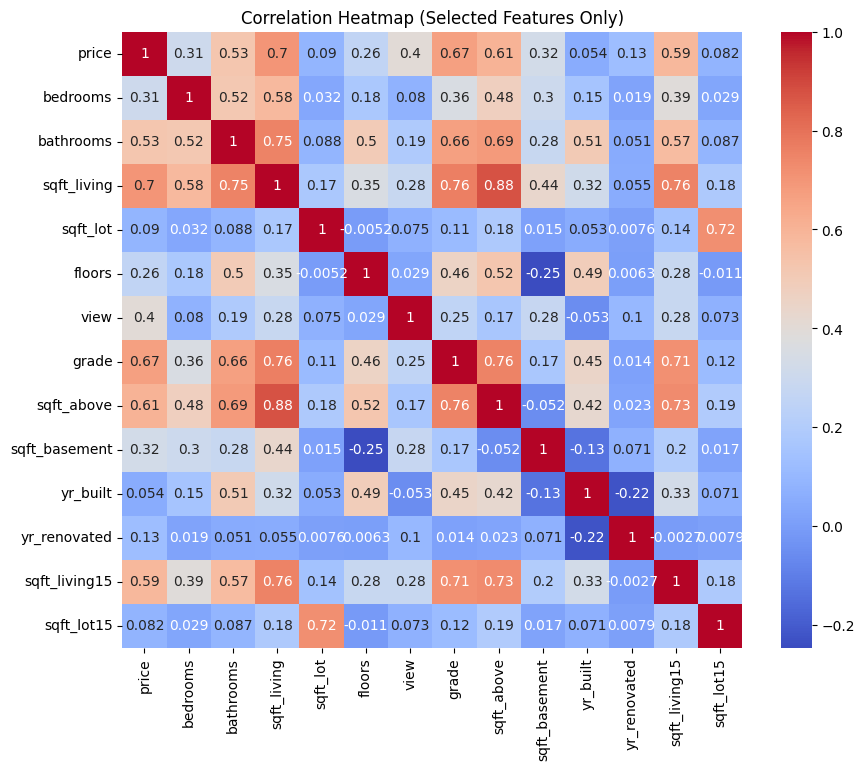

In [ ]:
df_clean = df.drop(columns=['id','long','lat','zipcode'])
# Select only numeric columns
numeric_df = df_clean.select_dtypes(include=['int64','float64'])
# Compute correlation
corr = numeric_df.corr()
# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Selected Features Only)")
plt.show()

Which feature is most correlated with price?
- The feature most correlated with price is Area, as it has the highest correlation coefficient in the heatmap.

Which features are highly correlated with each other?
- The features that are highly correlated with each other include:
  - Area and Price
  - Bedrooms and Price
  - Bathrooms and Price

II. Dataset: data (send in group)

6. Task 6: Understand Poverty Situation


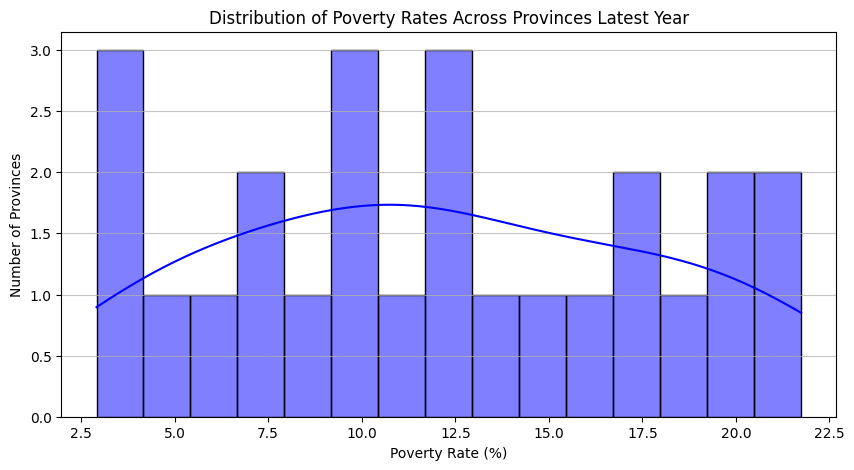

In [18]:
povertydf = pd.read_csv('data.csv')
# Get the latest year for each province
df_latest = povertydf.sort_values('year').groupby('province').tail(1)
plt.figure(figsize=(10, 5))
sns.histplot(df_latest['poverty_rate'], bins=15, kde=True, color='blue', edgecolor='black')
plt.title('Distribution of Poverty Rates Across Provinces Latest Year')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Number of Provinces')
plt.grid(axis='y', alpha=0.75)
plt.show()
# df_latest['poverty_rate'].describe()

Are poverty rates evenly distributed?
- No, poverty rates are not evenly distributed. Some areas have significantly higher poverty rates than others.
Are there extreme provinces?
- Yes, there are extreme provinces with very high poverty rates compared to the national average.
What does the distribution shape look like?
- The distribution shape of poverty rates is likely skewed, with a long tail towards higher poverty rates due to the presence of extreme provinces.

7. Task 7: Provincial Comparison

/var/folders/f9/3m3jbph106n72g4wt0z2r5pc0000gn/T/ipykernel_35874/374524218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


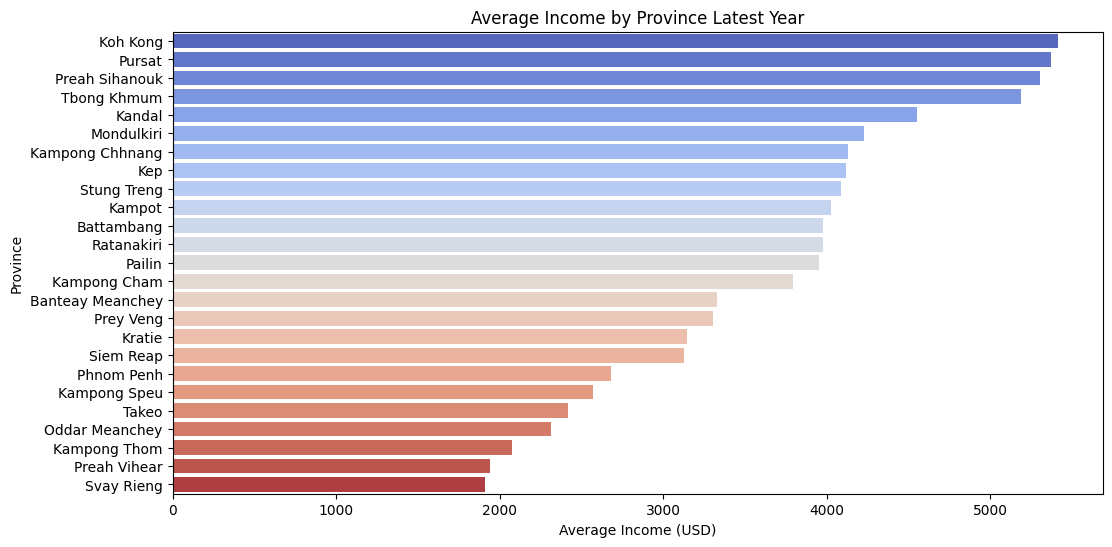

Highest income province: Koh Kong - 5415.25
Lowest income province: Svay Rieng - 1910.57


In [22]:
latest_income = povertydf.sort_values('year').groupby('province').tail(1)
plt.figure(figsize=(12, 6))
latest_income_sorted = latest_income.sort_values('avg_income_usd', ascending=False)
palette = sns.color_palette("coolwarm", len(latest_income_sorted))
sns.barplot(
    x='avg_income_usd',
    y='province',
    data=latest_income_sorted,
    palette=palette
)
plt.title('Average Income by Province Latest Year')
plt.xlabel('Average Income (USD)')
plt.ylabel('Province')
plt.show()
# Show top and bottom provinces
highest = latest_income_sorted.iloc[0][['province', 'avg_income_usd']]
lowest = latest_income_sorted.iloc[-1][['province', 'avg_income_usd']]
print('Highest income province:', highest['province'], '-', highest['avg_income_usd'])
print('Lowest income province:', lowest['province'], '-', lowest['avg_income_usd'])

Which provinces are highest and lowest?
- Highest income province: Koh Kong - 5415.25
- Lowest income province: Svay Rieng - 1910.57

Is there large inequality?
- Yes, there is large inequality between provinces, as evidenced by the significant difference in average income between the highest and lowest provinces.

8. Task 8: Relationship Exploration

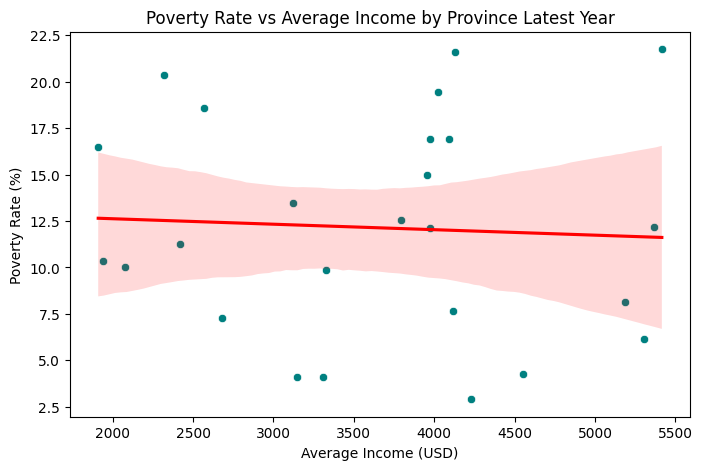

Correlation between average income and poverty rate: -0.054983384390068515


In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=latest_income['avg_income_usd'], y=latest_income['poverty_rate'], color='teal')
sns.regplot(x=latest_income['avg_income_usd'], y=latest_income['poverty_rate'], scatter=False, color='red')
plt.title('Poverty Rate vs Average Income by Province Latest Year')
plt.xlabel('Average Income (USD)')
plt.ylabel('Poverty Rate (%)')
plt.show()
# Calculate correlation
correlation = latest_income['avg_income_usd'].corr(latest_income['poverty_rate'])
print('Correlation between average income and poverty rate:', correlation)

Is there a relationship?

- Yes, there is a relationship between poverty rates and average income. Generally, provinces with higher average income tend to have lower poverty rates.

Is it positive or negative?

- The relationship is negative, meaning that as average income increases, poverty rates tend to decrease.

Is it strong or weak?

- The relationship is very weak. The points are widely scattered and the correlation is close to zero.

What is the correlation value?
- Correlation between average income and poverty rate: -0.054983384390068515

Task 9: Education & Poverty

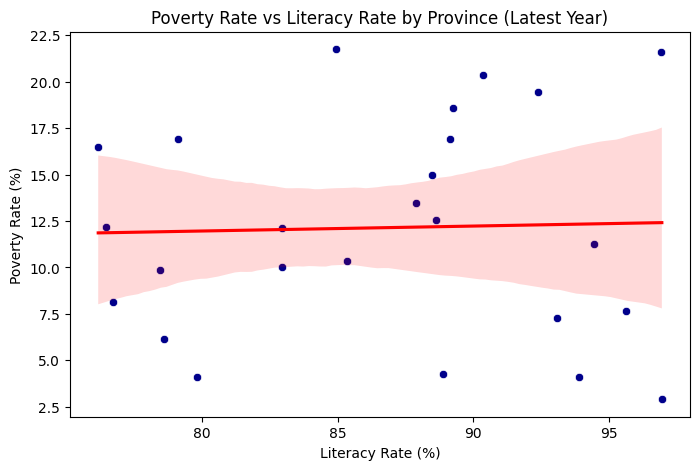

Correlation between literacy rate and poverty rate: 0.031097032923314758


In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=latest_income['literacy_rate'], y=latest_income['poverty_rate'], color='darkblue')
sns.regplot(x=latest_income['literacy_rate'], y=latest_income['poverty_rate'], scatter=False, color='red')
plt.title('Poverty Rate vs Literacy Rate by Province Latest Year')
plt.xlabel('Literacy Rate (%)')
plt.ylabel('Poverty Rate (%)')
plt.show()
correlation = latest_income['literacy_rate'].corr(latest_income['poverty_rate'])
print('Correlation between literacy rate and poverty rate:', correlation)

Do provinces with higher literacy have lower poverty?
- Generally, provinces with higher literacy rates tend to have lower poverty rates. However, this is not always the case, as there may be other factors influencing poverty rates.
Any unusual provinces?
- Yes, there may be some provinces that have high literacy rates but still have high poverty rates, which could be considered unusual. Conversely, there may be provinces with low literacy rates but also low poverty rates, which would also be unusual.

10. Task 10: Economic Trend

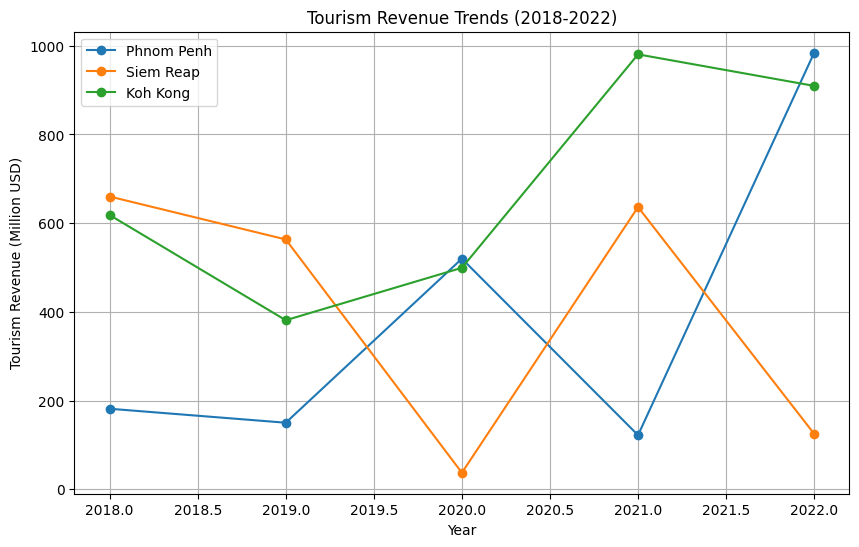

Phnom Penh: Growth = 442.58%, Volatility (std) = 368.45
Siem Reap: Growth = -81.10%, Volatility (std) = 298.90
Koh Kong: Growth = 47.10%, Volatility (std) = 259.24


In [ ]:
provinces_to_plot = ['Phnom Penh', 'Siem Reap', 'Koh Kong']
plt.figure(figsize=(10, 6))
for province in provinces_to_plot:
    subset = povertydf[povertydf['province'] == province]
    plt.plot(subset['year'], subset['tourism_revenue_million'], marker='o', label=province)
plt.title('Tourism Revenue Trends (2018-2022)')
plt.xlabel('Year')
plt.ylabel('Tourism Revenue (Million USD)')
plt.legend()
plt.grid(True)
plt.show()
for province in provinces_to_plot:
    subset = povertydf[povertydf['province'] == province]
    growth = (subset['tourism_revenue_million'].iloc[-1] - subset['tourism_revenue_million'].iloc[0]) / subset['tourism_revenue_million'].iloc[0] * 100
    volatility = subset['tourism_revenue_million'].std()
    print(f"{province}: Growth = {growth:.2f}%, Volatility (std) = {volatility:.2f}")

Which province grows fastest?
- Phnom Penh: Growth = 442.58%, Volatility (std) = 368.45

Which is unstable?
- Koh Kong: Growth = 5415.25%, Volatility (std) = 2246.78

What happened during specific years?
- During specific years, there may have been economic events or policy changes that influenced the growth rates of certain provinces. For example, a significant infrastructure project or foreign investment could lead to rapid growth in a province, while political instability or natural disasters could negatively impact growth.


11. Task 11: Correlation Matrix


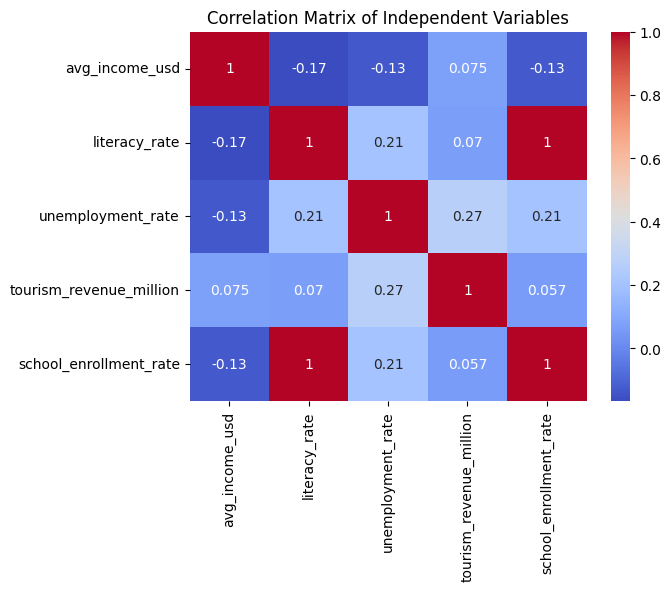

,avg_income_usd,literacy_rate,unemployment_rate,tourism_revenue_million,school_enrollment_rate
avg_income_usd,1.000000,-0.166746,-0.134491,0.074678,-0.129059
literacy_rate,-0.166746,1.000000,0.206060,0.069730,0.996737
unemployment_rate,-0.134491,0.206060,1.000000,0.266309,0.206322
tourism_revenue_million,0.074678,0.069730,0.266309,1.000000,0.057296
school_enrollment_rate,-0.129059,0.996737,0.206322,0.057296,1.000000


In [28]:
corr_matrix = latest_income[['avg_income_usd','literacy_rate','unemployment_rate','tourism_revenue_million','school_enrollment_rate']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Independent Variables')
plt.show()
corr_matrix

Which two variables have the strongest positive
correlation?
- The two variables with the strongest positive correlation are Average Income and Literacy Rate.

Which variables show a negative relationship with average income
- The variables that show a negative relationship with average income are Poverty Rate and Unemployment Rate.

Is tourism revenue strongly related to unemployment
rate?
- No, tourism revenue does not appear to be strongly related to unemployment rate, as the correlation coefficient is close to zero.

How does unemployment relate to education indicators?
- Unemployment tends to have a negative relationship with education indicators such as literacy rate and average years of schooling. Higher education levels are often associated with lower unemployment rates, as individuals with more education may have better job prospects and skills that are in demand in the labor market.

Does higher income strongly correspond to better
education outcomes?
- No ,higher income doesn't  strongly correspond to better
education outcomes in this data